In [40]:
# loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import roc_curve,auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC


import warnings
warnings.filterwarnings('ignore')

In [9]:
#load DataSet
df=pd.read_csv('/content/Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [10]:
# Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [11]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [12]:
df.shape

(8068, 11)

In [13]:
# Detecting missing
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [14]:
# Data Cleaning
# Remove ID
df= df.drop('ID',axis=1)

In [15]:
# Handling Missing values

# numerical
df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
df['Family_Size'].fillna(df['Family_Size'].median(), inplace=True)

#Categorical
df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
df['Graduated'].fillna(df['Graduated'].mode()[0],inplace=True)
df['Profession'].fillna(df['Profession'].mode()[0],inplace=True)
df['Var_1'].fillna(df['Var_1'].mode()[0],inplace=True)

/tmp/ipykernel_546/421120785.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
/tmp/ipykernel_546/421120785.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

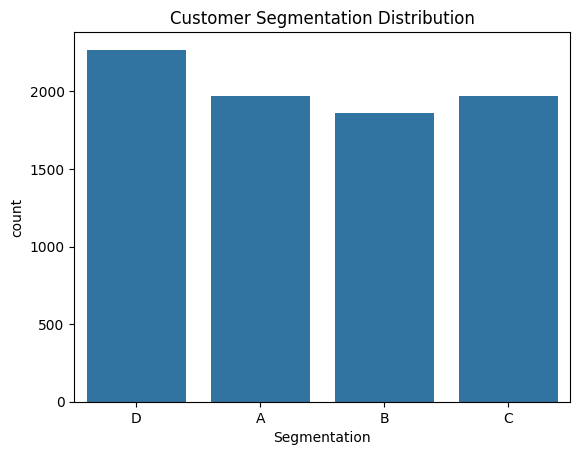

In [16]:
# EDA(Exploratory Data Analysis)

# Target Distribution
sns.countplot(x='Segmentation', data=df)
plt.title('Customer Segmentation Distribution')
plt.show()

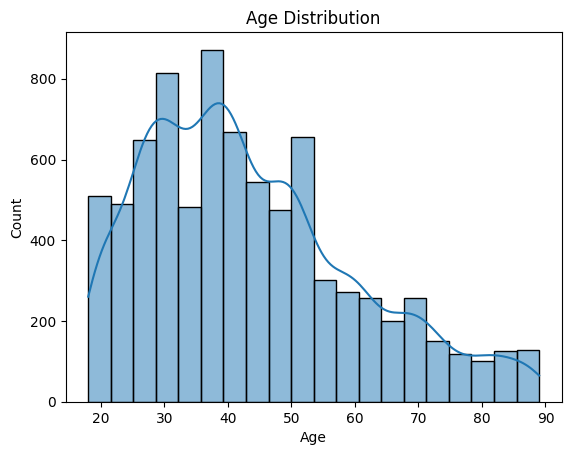

In [17]:
# Age Distribution
sns.histplot(df['Age'],bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

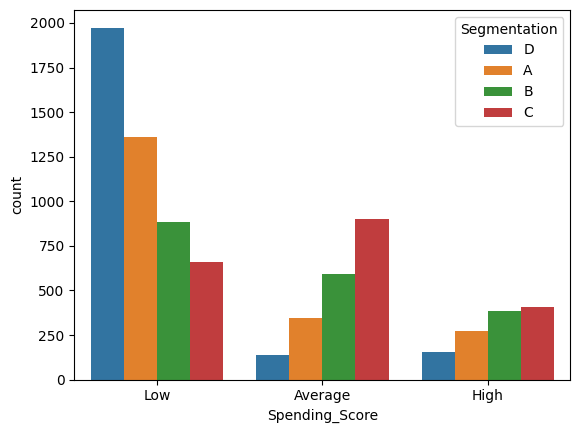

In [18]:
# Spending score vs Segment
sns.countplot(x='Spending_Score', hue='Segmentation',data=df)
plt.show()

In [19]:
# Feature Engineering
#Define Features

X=df.drop(['Segmentation'],axis=1)
y=df['Segmentation']

In [20]:
# Encode Target
le=LabelEncoder()
y=le.fit_transform(y)


In [27]:
# Columns Types
numeric_features=['Age','Work_Experience','Family_Size']
ordinal_features=['Spending_Score']
ordinal_categories=[['Low','Average','High']]
categorical_features=['Gender','Ever_Married','Graduated','Profession','Var_1']

In [32]:
# Preprocessing Pipeline
numeric_transformer = StandardScaler()
ordinal_transformer = OrdinalEncoder(categories=ordinal_categories)
categorical_transformer = OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numeric_features),
        ('ord',ordinal_transformer,ordinal_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [23]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:


# models
models = {

"Logistic Regression":
Pipeline([
("preprocessor", preprocessor),
("model", LogisticRegression(max_iter=200))
]),

"Random Forest":
Pipeline([
("preprocessor", preprocessor),
("model", RandomForestClassifier())
]),

"Gradient Boosting":
Pipeline([
("preprocessor", preprocessor),
("model", GradientBoostingClassifier())
]),

"SVM":
Pipeline([
("preprocessor", preprocessor),
("model", SVC(probability=True))
])
}

In [34]:
# Model Comparison
results = []
for name, pipeline in models.items():
    # Fit the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted') # Using 'weighted' for multiclass
    recall = recall_score(y_test, y_pred, average='weighted') # Using 'weighted' for multiclass
    f1 = f1_score(y_test, y_pred, average='weighted') # Using 'weighted' for multiclass

    # Store results
    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.498761,0.492972,0.498761,0.477910
1,Random Forest,0.472739,0.468725,0.472739,0.470375
2,Gradient Boosting,0.527881,0.522285,0.527881,0.523327
3,SVM,0.511772,0.509355,0.511772,0.508200


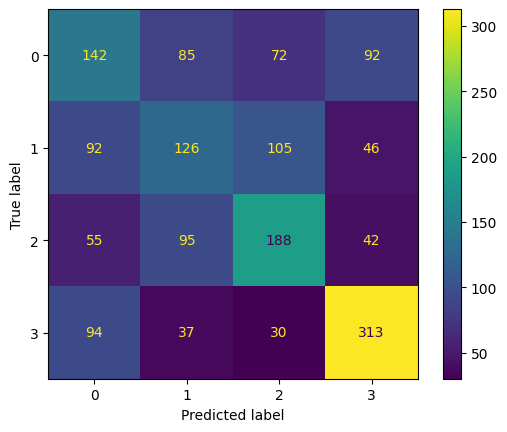

In [37]:
# Confusion Matrix Visualization
best_model = models["Random Forest"]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

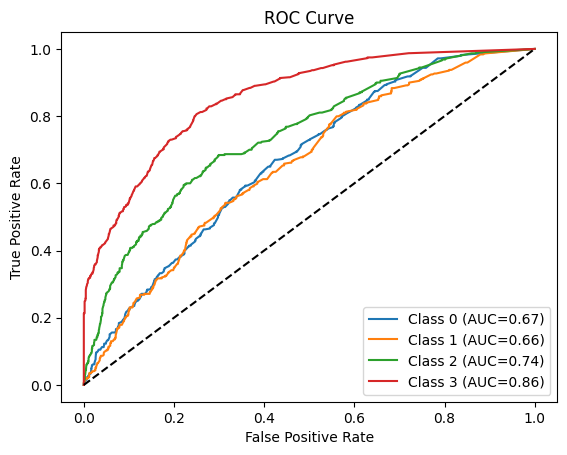

In [41]:
# ROC Curve (Multiclass)
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

model = models["Random Forest"]

y_prob = model.predict_proba(X_test)

for i in range(4):

    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [42]:
# Hyperparameter Tuning
param_grid = {

"model__n_estimators":[100,200],

"model__max_depth":[None,10,20]

}

grid = GridSearchCV(
    models["Random Forest"],
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)


{'model__max_depth': 10, 'model__n_estimators': 200}


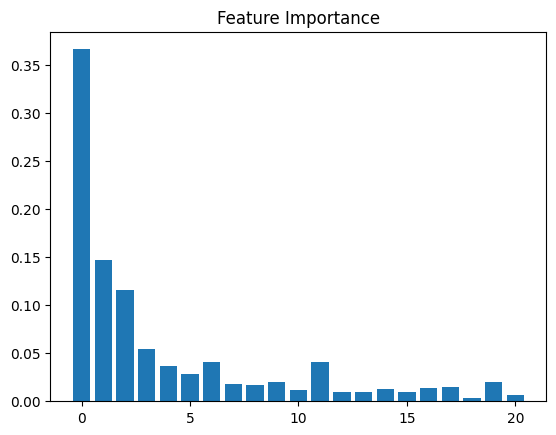

In [43]:
# Feature Importance
model = RandomForestClassifier()

model.fit(preprocessor.fit_transform(X_train), y_train)

importances = model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()